# Colab Notebook Skeleton SigLLM — MF + Q-Former + (Frozen) LLaMA for Yes/No

# **0. Setup Environment:**

### Clone Repository
To clone a private repo, you need a **Personal Access Token (PAT)**.
1. Go to [GitHub Tokens](https://github.com/settings/tokens).
2. Generate a new token (Classic) with **repo** scope.
3. Run the cell below and enter your credentials.

In [1]:
import os
from getpass import getpass

token = getpass("Enter your GitHub Personal Access Token (PAT): ")

repo_name = "SigLLM"
repo_url = f"https://{token}@github.com/QuocBaoBuiNguyen/{repo_name}.git"

!git clone {repo_url}
%cd SigLLM
!git checkout develop
!ls -a

Enter your GitHub Personal Access Token (PAT): ··········
Cloning into 'SigLLM'...
remote: Enumerating objects: 1544, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 1544 (delta 104), reused 175 (delta 86), pack-reused 1340 (from 1)
Receiving objects: 100% (1544/1544), 84.97 MiB | 19.00 MiB/s, done.
Resolving deltas: 100% (743/743), done.
/content/SigLLM
Already on 'develop'
Your branch is up to date with 'origin/develop'.
.   configs  env.yaml  .gitignore  prompts	     src
..  data     .git      notebooks   requirements.txt


In [ ]:
!git checkout develop
!git pull origin develop

Already on 'develop'
Your branch is up to date with 'origin/develop'.
From https://github.com/QuocBaoBuiNguyen/SigLLM
 * branch            develop    -> FETCH_HEAD
Already up to date.


In [ ]:
!git branch
# !git pull origin feat/optimize-dataset-in-batch-neg
# !git pull origin feat/optimize-loss-vs-concat-queries-instruction-vs-rmv-llma_proj
!git pull origin feat/opt-loss-upgrade-to-instructblip-model-using-bert-add-lora

* develop
From https://github.com/QuocBaoBuiNguyen/SigLLM
 * branch            feat/opt-loss-upgrade-to-instructblip-model-using-bert-add-lora -> FETCH_HEAD
Updating 1c22150..af86db5
Fast-forward
 configs/config.yaml                                |  88 ++--
 prompts/qformer_prompt_movie.txt                   |  12 +-
 src/sigllm/datasets/data_preprocessing.py          |  25 +
 .../datasets/qformer/qformer_alignment_builder.py  | 444 +++++++++++-------
 .../datasets/qformer/qformer_alignment_dataset.py  |  18 +-
 src/sigllm/datasets/qformer/qformer_loader.py      |  89 ++++
 .../models/multimodal/base/rec_base_model.py       |   4 +-
 src/sigllm/models/multimodal/qformer_rec_llm.py    | 356 +++++++++------
 .../models/projection/qformer_alignment_model.py   | 300 +++++++-----
 src/sigllm/models/q_former/hf_qformer_adapter.py   | 346 +++++++++++---
 src/sigllm/models/q_former/q_former.py             |  12 +-
 src/sigllm/models/q_former/text_encoder.py         |  30 --
 src/sigllm/pipeli

In [49]:
# !git checkout feat/opt-loss-upgrade-to-instructblip-model-using-bert-add-lora
# !git pull origin feat/opt-loss-upgrade-to-instructblip-model-using-bert-add-lora
# !git checkout experiment/ablation-zero-soft-tokens
# !git pull origin experiment/ablation-zero-soft-tokens
# !git checkout feat/stage3-two-step-tuning
# !git pull origin feat/stage3-two-step-tuning
!git checkout feat/swap-llm-qwen2
!git pull origin feat/swap-llm-qwen2

Already on 'feat/swap-llm-qwen2'
Your branch is up to date with 'origin/feat/swap-llm-qwen2'.
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9 (delta 4), reused 9 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 780 bytes | 390.00 KiB/s, done.
From https://github.com/QuocBaoBuiNguyen/SigLLM
 * branch            feat/swap-llm-qwen2 -> FETCH_HEAD
   c58d9b4..5bd20c0  feat/swap-llm-qwen2 -> origin/feat/swap-llm-qwen2
Updating c58d9b4..5bd20c0
Fast-forward
 configs/config.yaml                    | 2 +-
 src/sigllm/tasks/base/rec_base_task.py | 7 ++++---
 2 files changed, 5 insertions(+), 4 deletions(-)



### Reload (Must run after pulling new code)

In [50]:
import sys
import importlib
from types import ModuleType

imp = ModuleType('imp')
imp.reload = importlib.reload
sys.modules['imp'] = imp

# %load_ext autoreload
# %autoreload 2
%reload_ext autoreload

In [51]:
%env PYTHONPATH=src:$PYTHONPATH

env: PYTHONPATH=src:$PYTHONPATH


**Reasoning**:
Import torch and check for CUDA availability to verify that the GPU is accessible.



In [37]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


## Setup conda environment


In [6]:
!wget -c https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/Miniconda3.sh
!chmod +x /content/Miniconda3.sh
!bash /content/Miniconda3.sh -b -f -p /usr/local

--2026-05-23 13:29:13--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘/content/Miniconda3.sh’

/content/Miniconda3 100%[===================>] 155.62M   266MB/s    in 0.6s    

2026-05-23 13:29:14 (266 MB/s) - ‘/content/Miniconda3.sh’ saved [163179296/163179296]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTH

In [7]:
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages')

In [8]:
!conda --version

conda 26.3.2


In [9]:
!source /usr/local/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!source /usr/local/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
%%bash
set -e

source /usr/local/etc/profile.d/conda.sh

ENV_NAME="sigllm"
ENV_YAML="/content/SigLLM/env.yaml"

CACHE_DIR="/content/drive/MyDrive/SigLLM/colab_conda_cache"
ENV_PACK="$CACHE_DIR/${ENV_NAME}.tar.gz"
ENV_PREFIX="/usr/local/envs/${ENV_NAME}"

mkdir -p "$CACHE_DIR"

echo "Env prefix: $ENV_PREFIX"
echo "Env cache : $ENV_PACK"

if [ -d "$ENV_PREFIX" ] && [ -f "$ENV_PREFIX/bin/python" ]; then
    echo "Env already exists in this runtime. Skip setup."

elif [ -f "$ENV_PACK" ]; then
    echo "Found cached env pack. Restoring env..."
    rm -rf "$ENV_PREFIX"
    mkdir -p "$ENV_PREFIX"

    tar -xzf "$ENV_PACK" -C "$ENV_PREFIX"

    conda activate "$ENV_PREFIX"
    conda-unpack || true

    echo "Env restored from cache."

else
    echo "No cache found. Creating env from env.yaml..."
    conda env create -f "$ENV_YAML"

    conda activate "$ENV_NAME"

    echo "Installing conda-pack..."
    conda install -y conda-pack

    echo "Packing env to Drive cache..."
    "$ENV_PREFIX/bin/conda-pack" \
        -p "$ENV_PREFIX" \
        -o "$ENV_PACK" \
        --force

    echo "Env cache saved to: $ENV_PACK"
fi

echo "Done."

Env prefix: /usr/local/envs/sigllm
Env cache : /content/drive/MyDrive/SigLLM/colab_conda_cache/sigllm.tar.gz
Found cached env pack. Restoring env...
Env restored from cache.
Done.


In [12]:
# !source /usr/local/etc/profile.d/conda.sh && conda env create -f /content/SigLLM/env.yaml

In [13]:
!source /usr/local/etc/profile.d/conda.sh && \
conda activate sigllm && \
python -m pip install -U \
"transformers==4.38.2" \
"accelerate==0.27.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 160.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 162.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.2 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.13.4
    Uninstalling huggingface-hub-0.13.4:
      Successfully uninstalled huggingface-hub-0.13.4
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.13.2
    Uninstalling tokenizers-0.13.2:
      Successfully uninstalled tokenizers-0.13.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.28.0
    Uninstalling transformers-4.28.0:
      Successfully uninstalled transformers-4.28.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.16.0
    Uninstalling accelerate-0.16.0:
      Successfully uninstalled acc

In [14]:
!source /usr/local/etc/profile.d/conda.sh && conda env list


# conda environments:
#
# * -> active
# + -> frozen
base                     /usr/local
sigllm                   /usr/local/envs/sigllm



In [15]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm

### Run this only in case update env.yaml

In [ ]:
# !source /usr/local/etc/profile.d/conda.sh && conda env update --file env.yaml --prune

# **1. Dataset Preparation:**

## Download and prepare datasets

In [16]:
import sys
sys.path.insert(0, "src")

In [17]:
!rm -rf /content/SigLLM/data/processed/

In [18]:
!unzip /content/SigLLM/data/raw/ml-1m.zip -d /content/SigLLM/data/raw/

Archive:  /content/SigLLM/data/raw/ml-1m.zip
   creating: /content/SigLLM/data/raw/ml-1m/
  inflating: /content/SigLLM/data/raw/ml-1m/movies.dat  
  inflating: /content/SigLLM/data/raw/ml-1m/ratings.dat  
  inflating: /content/SigLLM/data/raw/ml-1m/README  
  inflating: /content/SigLLM/data/raw/ml-1m/users.dat  


## Primary ML-1M preprocessing: handles temporal splitting, ID remapping, and sequential history construction.


In [19]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/datasets/data_preprocessing.py

2026-05-23 20:34:16 | [1/10] Load raw tables | ratings + movies + users
2026-05-23 20:34:21 | Raw shapes | ratings=(1000209, 4), movies=(3883, 3), users=(6040, 5)
2026-05-23 20:34:21 | [2/10] Merge metadata | content-aware enrichment (title/genres)
2026-05-23 20:34:21 | Merged table | shape=(1000209, 6)
2026-05-23 20:34:21 | [3/10] Inspect time span | temporal coverage
2026-05-23 20:34:21 | Time extrema | 2000-04-25 -> 2003-02-28
2026-05-23 20:34:21 | Total months | 34
2026-05-23 20:34:21 | [4/10] Build time slots | prevent leakage via temporal split
2026-05-23 20:34:23 | Time bins | count=35, range=(0, 34)
2026-05-23 20:34:23 | Plot time histogram | volume vs slot for drift check
2026-05-23 20:34:23 | [5/10] Define temporal windows | train=[14, 15, 16, 17, 18, 19, 20, 21, 22, 23], valid=[24, 25, 26, 27, 28], test=[29, 30, 31, 32, 33]
2026-05-23 20:34:23 | [6/10] Create binary label | rating >= 4 ⇒ positive=1
2026-05-23 20:34:24 | Label stats | mean=0.575, std=0.494, positives=57.5%
20

### **Note:** The following cells are **JUST ONLY USE** for visualizing and exploring the prepared data.

/usr/local/lib/python3.12/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


INFO     2026-04-20 17:45:50 | [1/10] Load raw tables | ratings + movies + users           data_preprocessing.py:19

INFO     2026-04-20 17:45:54 | Raw shapes | ratings=(1000209, 4), movies=(3883, 3),        data_preprocessing.py:19
         users=(6040, 5)                                                                                           

INFO     2026-04-20 17:45:54 | [2/10] Merge metadata | content-aware enrichment            data_preprocessing.py:19
         (title/genres)                                                                                            

INFO     2026-04-20 17:45:54 | Merged table | shape=(1000209, 6)                           data_preprocessing.py:19

...

INFO     2026-04-20 17:45:57 | Validation/Test label rate | valid=0.528, test=0.545        data_preprocessing.py:19

INFO     2026-04-20 17:45:57 | Validation columns | uid, iid, rating, timestamp, title,    data_preprocessing.py:19
         genres, time, label                                                                                       

INFO     2026-04-20 17:45:57 | [7/10] Annotate split flag | train=-1, valid=0, test=1      data_preprocessing.py:19

INFO     2026-04-20 17:45:57 | [8/10] Concatenate & sort | order by (uid, timestamp)       data_preprocessing.py:19

KeyboardInterrupt: 

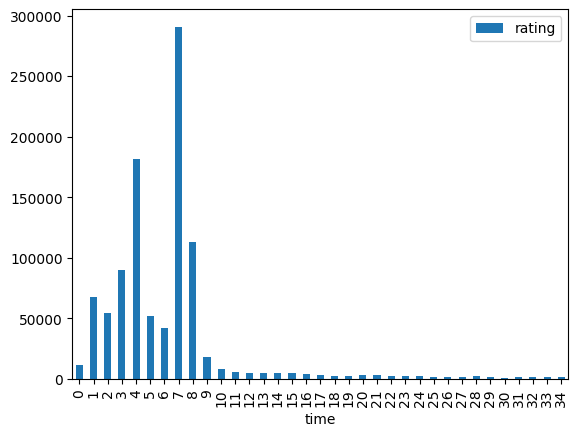

In [ ]:
from sigllm.datasets import build_ml1m

train_df, valid_df, test_df, users_map, items_map = build_ml1m(
    raw_dir="/content/SigLLM/data/raw/ml-1m/",
    out_dir="/content/SigLLM/data/processed/ml-1m",
)

print(f"✓ Train: {len(train_df):,} rows")
print(f"✓ Valid: {len(valid_df):,} rows")
print(f"✓ Test: {len(test_df):,} rows")

In [ ]:
import pandas as pd

path = "/content/SigLLM/data/processed/ml-1m/"
files = ["users_map.pkl", "items_map.pkl", "train_ood2.pkl"]

for f in files:
    data = pd.read_pickle(path + f)
    print(f"\nFile: {f}")
    print(dict(list(data.items())[:50]) if isinstance(data, dict) else data[:50])

## Evaluation-specific tagging: segments the test set into "Warm" (high frequency) and "Strict-Cold" (unseen) groups.

In [20]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/datasets/preprocess_test_cold_warm.py

2026-05-23 20:34:28 | [1/5] Load datasets | dir=/content/SigLLM/data/processed/ml-1m/
2026-05-23 20:34:28 | Loaded shapes | train=(33891, 10), test=(7331, 10)
2026-05-23 20:34:28 | [2/5] Analyze User Interactions | Threshold > 3
2026-05-23 20:34:28 | User stats | Total=740, Warm=635
2026-05-23 20:34:28 | [3/5] Analyze Item Interactions | Threshold > 3
2026-05-23 20:34:28 | Item stats | Total=3087, Warm=2058
2026-05-23 20:34:28 | [4/5] Compute Warm/Cold Flags for Test Set
2026-05-23 20:34:29 | Flag distribution | Warm=48.0%, Cold=0.4%
2026-05-23 20:34:29 | Test DataFrame Stats | 
          not_cold  ...         cold
count  7331.000000  ...  7331.000000
mean      0.566498  ...     0.003547
std       0.495592  ...     0.059452
min       0.000000  ...     0.000000
25%       0.000000  ...     0.000000
50%       1.000000  ...     0.000000
75%       1.000000  ...     0.000000
max       1.000000  ...     1.000000

[8 rows x 3 columns]
2026-05-23 20:34:29 | [5/5] Save Result | path=/content/Sig

### **Note:** The following cells are **JUST ONLY USE** for visualizing and exploring the prepared data.

In [ ]:
from sigllm.datasets import process_warm_cold

process_warm_cold()

## QFormer Dataset

In [21]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \python /content/SigLLM/src/sigllm/pipelines/multimodal/build_qformer_dataset.py

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
2026-05-23 20:34:32 | Build config | data_dir=/content/SigLLM/data/processed/ml-1m/, seed=2025, item_pair_window=2, max_item_item_pairs=None, max_user_item_pairs=None, include_user_item=True
2026-05-23 20:34:33 | Built Q-Former pkl | /content/SigLLM/data/processed/ml-1m/train_ood2.pkl -> /content/SigLLM/data/processed/ml-1m/train_qformer_ood2.pkl
2026-05-23 20:34:34 | Built Q-Former pkl | /content/SigLLM/data/processed/ml-1m/valid_ood2.pkl -> /content/SigLLM/data/processed/ml-1m/valid_qformer_ood2.pkl
2026-05-23 20:34:34 | Built Q-Former pkl | /content/SigLLM/data/processed/ml-1m/test_ood2.pkl -> /content/SigLLM/data/processed/ml-1m/test_qformer_ood2.pkl


# **2. Training Stages (3 steps)**

In [41]:
!mkdir -p /content/SigLLM/ckpt/llm/base/
!cp -r /content/drive/MyDrive/SigLLM/llm/vicuna-7b/*  /content/SigLLM/ckpt/llm/base/

cp: cannot stat '/content/drive/MyDrive/SigLLM/llm/vicuna-7b/*': No such file or directory


In [22]:
!mkdir -p /content/SigLLM/ckpt/mf/
!cp -r /content/drive/MyDrive/SigLLM/mf/* /content/SigLLM/ckpt/mf/

In [29]:
# !mkdir -p /content/SigLLM/ckpt/qformer_stage1/
# !cp -r /content/drive/MyDrive/SigLLM/qformer_stage1/* /content/SigLLM/ckpt/qformer_stage1/
!mkdir -p /content/SigLLM/ckpt/qformer_stage1/
!cp -r /content/drive/MyDrive/SigLLM/qformer_stage1/4layers_23_5_2026/* /content/SigLLM/ckpt/qformer_stage1/

In [28]:
# !mkdir -p /content/SigLLM/ckpt/qformer_stage2/
# !cp -r /content/drive/MyDrive/SigLLM/qformer_stage2/* /content/SigLLM/ckpt/qformer_stage2/
!mkdir -p /content/SigLLM/ckpt/qformer_stage2_qwen2/
!cp -r /content/drive/MyDrive/SigLLM/qformer_stage2/4layers_23_5_2026_stage2/* /content/SigLLM/ckpt/qformer_stage2_qwen2/


In [25]:
!mkdir -p /content/SigLLM/ckpt/qformer_stage3_step1_lora/qwen2-7b-lora/
# !cp -r /content/drive/MyDrive/SigLLM/llm/lora/* /content/SigLLM/ckpt/qformer_stage3_step1_lora/
!cp -r /content/drive/MyDrive/SigLLM/llm/qwen2-7b-lora/* /content/SigLLM/ckpt/qformer_stage3_step1_lora/qwen2-7b-lora/

In [23]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/pipelines/llm/pull_llm_model.py

Pulling model from Qwen/Qwen2-7B...
/usr/local/envs/sigllm/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
tokenizer_config.json: 1.29kB [00:00, 5.34MB/s]
vocab.json: 2.78MB [00:00, 109MB/s]
merges.txt: 1.67MB [00:00, 123MB/s]
tokenizer.json: 7.03MB [00:00, 180MB/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
config.json: 100% 664/664 [00:00<00:00, 120kB/s]
/usr/local/envs/sigllm/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model.safetensors.index.json: 27.8kB [00:00, 101M

In [ ]:
!cp -r /content/SigLLM/ckpt/llm/qwen2-7b-base/* /content/drive/MyDrive/SigLLM/llm/qwen_2/

## Stage 0 — Train MF (Collaborative Filtering backbone)
- Train MF to produce user/item embeddings `e_u`, `e_i` as the recommendation signal, then freeze MF for later steps.


In [ ]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/pipelines/rec/train_rec_baseline.py

2026-05-12 23:58:52 | Loaded config | cfg_path=configs/config.yaml
2026-05-12 23:58:52 | Dataset dir | /content/SigLLM/data/processed/ml-1m/
2026-05-12 23:58:52 | Dataset key | movie_ood
2026-05-12 23:58:52 | Baseline mode | need_train=True, warm_or_cold=warm
2026-05-12 23:58:52 | User num: | 839
2026-05-12 23:58:52 | Item num: | 3256
2026-05-12 23:58:52 | warm data size: | 3522
2026-05-12 23:58:54 | Users with only one interaction | 30
2026-05-12 23:58:54 | Users with only one class | 44
2026-05-12 23:58:54 | Computed user AUC count | 282
2026-05-12 23:58:54 | Average User AUC | 0.523856
2026-05-12 23:58:54 | Time taken to calculate user AUC | 0.30 seconds
2026-05-12 23:58:54 | Users with only one interaction | 32
2026-05-12 23:58:54 | Users with only one class | 55
2026-05-12 23:58:54 | Computed user AUC count | 151
2026-05-12 23:58:54 | Average User AUC | 0.496512
2026-05-12 23:58:54 | Time taken to calculate user AUC | 0.16 seconds
2026-05-12 23:58:54 | Epoch 0: Valid AUC: 0.5086, 

In [ ]:
# !mkdir -p /content/drive/MyDrive/SigLLM/mf
# !cp -r /content/SigLLM/ckpt/mf/* /content/drive/MyDrive/SigLLM/mf/

## Stage 1 — Representation Pretraining (Q-Former + projector, no Yes/No forcing yet)
- Pretrain Q-Former to transform `(e_u, e_i)` into stable, informative soft tokens (alignment/contrastive or pairwise objectives), so the representation is well-formed before plugging into the LLM.

In [27]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \python /content/SigLLM/src/sigllm/pipelines/multimodal/train_qformer_stage1_representation.py

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
Successfully loaded the pretrained rec model from /content/SigLLM/ckpt/mf/mf_model.pth
Freeze rec encoder completed
/usr/local/envs/sigllm/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-23 15:32:26 | Training setup | seed=2025, output_dir=/content/SigLLM/ckpt/qformer_stage1/
[train_step] batch_size=256 type_counts={'user_item': 92, 'item_text': 17, 'item_item': 147} u.shape=(256,) i_left.shape=(256,) i_right.shape=(256,)
[train_step] sample[0] type=user_item u=763 i_left=354 i_right=0
[train_step] s

In [29]:
# !mkdir -p /content/drive/MyDrive/SigLLM/qformer_stage1/4layers_23_5_2026/
!cp -r /content/SigLLM/ckpt/qformer_stage1/* /content/drive/MyDrive/SigLLM/qformer_stage1/4layers_23_5_2026/

## Stage 2 — Generative pretrainin

In [29]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/pipelines/multimodal/train_qformer_stage2_generative.py

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
2026-05-23 17:33:38 | Loaded pretrained MF | /content/SigLLM/ckpt/mf/mf_model.pth
/usr/local/envs/sigllm/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 8.36kB/s]
config.json: 100% 570/570 [00:00<00:00, 105kB/s]
vocab.txt: 232kB [00:00, 4.25MB/s]
tokenizer.json: 466kB [00:00, 2.50MB/s]
2026-05-23 17:33:41 | Loaded Phase 1 Q-Former | /content/SigLLM/ckpt/qformer_stage1/qformer_stage1_best_qformer.pth
Special tokens have been added in the vocabulary, make sur

In [33]:
# !mkdir -p /content/drive/MyDrive/SigLLM/qformer_stage2/22_5_2026/
!cp -r /content/SigLLM/ckpt/qformer_stage2_qwen2/* /content/drive/MyDrive/SigLLM/qformer_stage2/4layers_23_5_2026_stage2/

## Stage 3 — Yes/No Fine-tuning with Frozen LLaMA + LoRA (force constrained outputs)
- LoRA Instruction tuning for recommendation task
- Inject the soft tokens into a fixed prompt and fine-tune Q-Former (+ projector) using LM loss computed only on the single “Yes/No” answer token, keeping the entire LLaMA frozen to enforce the constrained response.

In [34]:
!source /usr/local/etc/profile.d/conda.sh && \
conda activate sigllm && \
export TOKENIZERS_PARALLELISM=false && \
python /content/SigLLM/src/sigllm/pipelines/multimodal/train_qformer_stage3_step1_lora.py --cfg-path /content/SigLLM/configs/config.yaml

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
Not using distributed mode
2026-05-23 17:52:22 | data path | /content/SigLLM/data/processed/ml-1m/train_ood2.pkl | data size: (33891, 7)
2026-05-23 17:52:22 | Movie OOD datasets, max history length: | 10
2026-05-23 17:52:22 | data path | /content/SigLLM/data/processed/ml-1m/valid_ood2.pkl | data size: (10401, 7)
2026-05-23 17:52:22 | Movie OOD datasets, max history length: | 10
2026-05-23 17:52:22 | data path | /content/SigLLM/data/processed/ml-1m/test_ood2.pkl | data size: (7331, 7)
2026-05-23 17:52:22 | Movie OOD datasets, max history length: | 10
2026-05-23 17:52:23 | Running MiniGPT4Rec_v2 initialization
2026-05-23 17:52:23 | Loading Rec_model
2026-05-23 17:52:23 | Initializing Matrix Factorization model
2026-05-23 17:52:2

In [52]:
# !mkdir -p /content/drive/MyDrive/SigLLM/llm/lora/qwen2-7b-base/
!cp -r /content/SigLLM/ckpt/qformer_stage3_step1_lora_qwen2/20260523105/* /content/drive/MyDrive/SigLLM/llm/qwen2-7b-lora/

In [41]:
!source /usr/local/etc/profile.d/conda.sh && \
conda activate sigllm && \
export TOKENIZERS_PARALLELISM=false && \
python /content/SigLLM/src/sigllm/pipelines/multimodal/train_qformer_stage3_step2_cie.py --cfg-path /content/SigLLM/configs/config.yaml

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
Not using distributed mode
2026-05-23 22:23:13 | data path | /content/SigLLM/data/processed/ml-1m/train_ood2.pkl | data size: (33891, 7)
2026-05-23 22:23:13 | Movie OOD datasets, max history length: | 10
2026-05-23 22:23:13 | data path | /content/SigLLM/data/processed/ml-1m/valid_ood2.pkl | data size: (10401, 7)
2026-05-23 22:23:13 | Movie OOD datasets, max history length: | 10
2026-05-23 22:23:13 | data path | /content/SigLLM/data/processed/ml-1m/test_ood2.pkl | data size: (7331, 7)
2026-05-23 22:23:13 | Movie OOD datasets, max history length: | 10
2026-05-23 22:23:14 | Running MiniGPT4Rec_v2 initialization
2026-05-23 22:23:14 | Loading Rec_model
2026-05-23 22:23:14 | Initializing Matrix Factorization model
2026-05-23 22:23:1

In [43]:
!mkdir -p /content/drive/MyDrive/SigLLM/qformer_stage3_step2_cie/qwen2_23_05_2026_0_70976
!cp -r /content/SigLLM/ckpt/qformer_stage3_step2_cie_qwen2/* /content/drive/MyDrive/SigLLM/qformer_stage3_step2_cie/qwen2_23_05_2026_0_70976

# **3. Evaluation**

## 3.1 Offline metrics (classification)
- Compute AUC, logloss, accuracy/F1 on val/test (from Yes/No probabilities or decoded token outputs).


## 3.2 Generation check (Yes/No constraint)
- Evaluate with `max_new_tokens=1`, accept only “Yes/No”; log invalid outputs and compute a confusion matrix.

## 3.3 Baselines & ablations
- Compare: MF-only, MF+Q-Former (no LLM), MF+Q-Former+Frozen LLaMA; ablate K negatives / #query tokens / proj_token_num.


In [52]:
!source /usr/local/etc/profile.d/conda.sh && \
conda activate sigllm && \
export TOKENIZERS_PARALLELISM=false && \
python -m sigllm.pipelines.multimodal.train_qformer_stage3_step2_cie --cfg-path configs/config.yaml \
--options model.ablate_soft_tokens=True run.evaluate=True

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
Not using distributed mode
2026-05-23 23:49:19 | data path | /content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl | data size: (3522, 7)
2026-05-23 23:49:19 | Movie OOD datasets, max history length: | 10
2026-05-23 23:49:19 | data path | /content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl | data size: (3178, 7)
2026-05-23 23:49:19 | Movie OOD datasets, max history length: | 10
2026-05-23 23:49:20 | ABLATION ACTIVE | ablate_soft_tokens=True → target_llm and interacted_llm_flat will be zeroed before injection (Information flow log will show target_llm mean/std=0).
2026-05-23 23:49:20 | Running MiniGPT4Rec_v2 initialization
2026-05-23 23:49:20 | Loading Rec_model
2026-05-23 23:49:20 | Initializing Matrix Factoriz

In [53]:
!source /usr/local/etc/profile.d/conda.sh && \
conda activate sigllm && \
export TOKENIZERS_PARALLELISM=false && \
python -m sigllm.pipelines.multimodal.train_qformer_stage3_step2_cie \
--cfg-path configs/config.yaml \
--options run.evaluate=True

/usr/local/envs/sigllm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
Not using distributed mode
2026-05-23 23:53:30 | data path | /content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl | data size: (3522, 7)
2026-05-23 23:53:30 | Movie OOD datasets, max history length: | 10
2026-05-23 23:53:31 | data path | /content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl | data size: (3178, 7)
2026-05-23 23:53:31 | Movie OOD datasets, max history length: | 10
2026-05-23 23:53:31 | Running MiniGPT4Rec_v2 initialization
2026-05-23 23:53:31 | Loading Rec_model
2026-05-23 23:53:31 | Initializing Matrix Factorization model
2026-05-23 23:53:31 | Successfully loaded the pretrained model
2026-05-23 23:53:31 | Freeze rec encoder
2026-05-23 23:53:31 | Loading Rec_model Done
2026-05-23 23:53:31 | Loadin

# **4. Others**

## This script initializes the Q-Former Alignment Dataset and extracts a small  subset of samples (e.g., first 5 records) to verify the data loading pipeline, instruction formatting, and negative sampling logic.

In [ ]:
import json
import torch
from pathlib import Path
from box import Box
from sigllm.datasets import QFormerAlignmentDataset

def build_and_save_samples(output_path="dataset_samples.json", num_samples=5):
    # 1. Giả lập cấu trúc Config mà Dataset yêu cầu
    # Bạn cần thay đổi 'path/to/your/storage' thành đường dẫn chứa file 'train_ood2.pkl'
    config = Box({
        "build_info": {
            "storage": Path("/content/SigLLM/data/processed/ml-1m/") # Thay đổi đường dẫn thực tế ở đây
        }
    })

    try:
        # 2. Khởi tạo dataset
        # Lưu ý: filename="train_ood2" (không cần đuôi .pkl vì class tự thêm)
        dataset = QFormerAlignmentDataset(
            config=config,
            filename="train_ood2.pkl",
            neg_k=5,
            p_fixed=0.5
        )

        samples_to_save = []

        # 3. Lấy ra n records đầu tiên
        print(f"Bắt đầu lấy {num_samples} mẫu...")
        for i in range(num_samples):
            # Lấy sample (hàm __getitem__ sẽ được gọi)
            sample = dataset[i]

            # Chuyển tensor sang list/int để có thể save JSON
            readable_sample = {
                "sample_index": i,
                "user_id": sample["u"].item(),
                "pos_item_id": sample["i_pos"].item(),
                "neg_item_ids": sample["i_negs"].tolist(),
                "instruction": sample["instruction"],
                "item_text": sample["item_text"]
            }
            samples_to_save.append(readable_sample)

            print(f"Đã lấy xong sample {i}")

        # 4. Lưu vào file JSON để xem cho "sướng"
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(samples_to_save, f, indent=4, ensure_ascii=False)

        print(f"\n--- THÀNH CÔNG ---")
        print(f"Kết quả đã được lưu tại: {output_path}")

    except Exception as e:
        print(f"Lỗi khi build dataset: {e}")


build_and_save_samples()

[02/21/26 14:39:43] INFO     data path |                                            qformer_alignment_dataset.py:22
                             /content/SigLLM/data/processed/ml-1m/train_ood2.pkl                                   

                    INFO     users with positives | 719                             qformer_alignment_dataset.py:22

                    INFO     item vocab | 3087                                      qformer_alignment_dataset.py:22

Bắt đầu lấy 5 mẫu...
Đã lấy xong sample 0
Đã lấy xong sample 1
Đã lấy xong sample 2
Đã lấy xong sample 3
Đã lấy xong sample 4

--- THÀNH CÔNG ---
Kết quả đã được lưu tại: dataset_samples.json


In [ ]:
"""
Robust Data Format Converter
----------------------------
Fixed issues:
1. Support for Dictionary-based .pkl files (converts to 2-column DataFrame).
2. Support for 'ISO-8859-1' encoding in .dat files to prevent decode errors.
"""

import pandas as pd
from pathlib import Path

def convert_to_excel(input_path: str, output_path: str = None, delimiter: str = '::'):
    source = Path(input_path)
    if not output_path:
        output_path = source.with_suffix('.xlsx')

    print(f"--- Processing: {source.name} ---")

    try:
        # 1. Handle Pickle files
        if source.suffix.lower() == '.pkl':
            data = pd.read_pickle(input_path)

            # Check if data is a dictionary instead of a DataFrame
            if isinstance(data, dict):
                print(f"Note: Dictionary detected. Converting to key-value pairs.")
                # Convert dict to DataFrame for Excel compatibility
                df = pd.DataFrame(list(data.items()), columns=['Key', 'Value'])
            else:
                df = data
            print(f"Status: Loaded Pickle successfully.")

        # 2. Handle .dat files
        elif source.suffix.lower() == '.dat':
            # Use encoding='ISO-8859-1' to handle special characters in movie titles
            df = pd.read_csv(
                input_path,
                sep=delimiter,
                engine='python',
                header=None,
                encoding='ISO-8859-1'
            )
            print(f"Status: Loaded DAT file with Latin-1 encoding.")

        else:
            print(f"Error: Unsupported format {source.suffix}")
            return

        # 3. Export to Excel
        df.to_excel(output_path, index=False)
        print(f"Success: Saved to -> {output_path}")

    except Exception as e:
        print(f"Failed to convert: {str(e)}")

convert_to_excel("/content/SigLLM/data/processed/ml-1m/train_ood2.pkl")
convert_to_excel("/content/SigLLM/data/processed/ml-1m/users_map.pkl")
convert_to_excel("/content/SigLLM/data/processed/ml-1m/items_map.pkl")
convert_to_excel("/content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl")

convert_to_excel("/content/SigLLM/data/raw/ml-1m/ratings.dat", delimiter='::')
convert_to_excel("/content/SigLLM/data/raw/ml-1m/users.dat", delimiter='::')
convert_to_excel("/content/SigLLM/data/raw/ml-1m/movies.dat", delimiter='::')

--- Processing: train_ood2.pkl ---
Status: Loaded Pickle successfully.
Success: Saved to -> /content/SigLLM/data/processed/ml-1m/train_ood2.xlsx
--- Processing: users_map.pkl ---
Note: Dictionary detected. Converting to key-value pairs.
Status: Loaded Pickle successfully.
Success: Saved to -> /content/SigLLM/data/processed/ml-1m/users_map.xlsx
--- Processing: items_map.pkl ---
Note: Dictionary detected. Converting to key-value pairs.
Status: Loaded Pickle successfully.
Success: Saved to -> /content/SigLLM/data/processed/ml-1m/items_map.xlsx
--- Processing: test_warm_cold_ood2.pkl ---
Status: Loaded Pickle successfully.
Success: Saved to -> /content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.xlsx
--- Processing: ratings.dat ---
Status: Loaded DAT file with Latin-1 encoding.
Success: Saved to -> /content/SigLLM/data/raw/ml-1m/ratings.xlsx
--- Processing: users.dat ---
Status: Loaded DAT file with Latin-1 encoding.
Success: Saved to -> /content/SigLLM/data/raw/ml-1m/users.xlsx
--- Pr

In [ ]:
!cd /content && wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-20m.zip
!cd /content && unzip -q ml-20m.zip
!ls -la /content/ml-20m | head

ml-20m.zip.1        100%[===================>] 189.50M  27.4MB/s    in 7.2s    
replace ml-20m/genome-scores.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/genome-tags.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/links.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/movies.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/ratings.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
y
replace ml-20m/README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: replace ml-20m/tags.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
total 855096
drwxr-xr-x 2 root root      4096 Feb 19 09:03 .
drwxr-xr-x 1 root root      4096 Feb 19 09:02 ..
-rw-r--r-- 1 root root 323544381 Oct 17  2016 genome-scores.csv
-rw-r--r-- 1 root root     18103 Oct 17  2016 genome-tags.csv
-rw-r--r-- 1 root root    570090 Oct 17  2016 links.csv
-rw-r--r-- 1 root root   1397542 Mar 31  2015 movies.csv
-rw-r--r-- 1 root root 533444411 Mar 31  2015 ratings.csv
-rw-r--r-- 1 root root     10261 O

In [ ]:
import pandas as pd

# Đường dẫn ví dụ: /content/ml-20m/
ROOT = "/content/ml-20m"

movies = pd.read_csv(f"{ROOT}/movies.csv")          # movieId,title,genres
tags = pd.read_csv(f"{ROOT}/tags.csv")              # userId,movieId,tag,timestamp
g_tags = pd.read_csv(f"{ROOT}/genome-tags.csv")     # tagId,tag
g_scores = pd.read_csv(f"{ROOT}/genome-scores.csv") # movieId,tagId,relevance

movie_id = 1  # đổi ID bạn muốn xem

m = movies[movies.movieId == movie_id].iloc[0]
title = m["title"]
# year: lấy 4 số trong ngoặc nếu có
import re
mm = re.search(r"\((\d{4})\)", title)
year = mm.group(1) if mm else "NA"
genres = m["genres"].replace("|", ", ")

top_user_tags = (tags[tags.movieId == movie_id]["tag"]
                 .value_counts()
                 .head(15)
                 .index
                 .tolist())

top_genome = (g_scores[g_scores.movieId == movie_id]
              .merge(g_tags, on="tagId", how="left")
              .sort_values("relevance", ascending=False)
              .head(25))

top_genome_tags_25 = [f'{row["tag"]}({row["relevance"]:.2f})' for _, row in top_genome.iterrows()]

text = (
f"Movie: {title} ({year}).\n"
f"Genres: {genres}.\n"
f"User tags: {', '.join(top_user_tags) if top_user_tags else 'NA'}.\n"
f"Key attributes (genome): {', '.join(top_genome_tags_25)}."
)

print(text)

Movie: Toy Story (1995) (1995).
Genres: Adventure, Animation, Children, Comedy, Fantasy.
User tags: Pixar, animation, Disney, Tom Hanks, computer animation, children, funny, witty, toys, comedy, family, pixar, time travel, humorous, animated.
Key attributes (genome): toys(1.00), computer animation(1.00), pixar animation(1.00), kids and family(0.99), animation(0.99), kids(0.98), pixar(0.97), children(0.96), cartoon(0.96), imdb top 250(0.94), animated(0.93), childhood(0.93), great movie(0.92), disney animated feature(0.91), friendship(0.91), story(0.91), light(0.90), adventure(0.89), original(0.88), fun(0.88), disney(0.87), family(0.85), unlikely friendships(0.84), good(0.84), great(0.84).


In [ ]:
!cd /content && wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-1m.zip
!cd /content && unzip -q ml-1m.zip
!ls -la /content/ml-1m | head

ml-1m.zip.1         100%[===================>]   5.64M  10.7MB/s    in 0.5s    
replace ml-1m/movies.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/ratings.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/users.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
total 24336
drwxr-x--- 2 root root     4096 Feb 19 09:06 .
drwxr-xr-x 1 root root     4096 Feb 19 09:06 ..
-rw-r----- 1 root root   171308 Mar 26  2003 movies.dat
-rw-r----- 1 root root 24594131 Feb 28  2003 ratings.dat
-rw-r----- 1 root root     5577 Jan 29  2016 README
-rw-r----- 1 root root   134368 Feb 28  2003 users.dat


In [ ]:
import pandas as pd
import re

ROOT = "/content/ml-1m"

# ML-1M dùng delimiter '::' và encoding latin-1
movies = pd.read_csv(
    f"{ROOT}/movies.dat",
    sep="::",
    engine="python",
    header=None,
    names=["movieId", "title", "genres"],
    encoding="latin-1",
)

ratings = pd.read_csv(
    f"{ROOT}/ratings.dat",
    sep="::",
    engine="python",
    header=None,
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1",
)

users = pd.read_csv(
    f"{ROOT}/users.dat",
    sep="::",
    engine="python",
    header=None,
    names=["userId", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)

# Mapping tuổi và nghề (theo chuẩn ML-1M docs)
AGE_MAP = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+",
}

OCC_MAP = {
    0: "other/not specified",
    1: "academic/educator",
    2: "artist",
    3: "clerical/admin",
    4: "college/grad student",
    5: "customer service",
    6: "doctor/health care",
    7: "executive/managerial",
    8: "farmer",
    9: "homemaker",
    10: "K-12 student",
    11: "lawyer",
    12: "programmer",
    13: "retired",
    14: "sales/marketing",
    15: "scientist",
    16: "self-employed",
    17: "technician/engineer",
    18: "tradesman/craftsman",
    19: "unemployed",
    20: "writer",
}

def make_movie_card(movie_id: int, like_threshold: float = 4.0, top_k: int = 10) -> str:
    m = movies[movies.movieId == movie_id]
    if m.empty:
        return f"Không tìm thấy movieId={movie_id}"
    m = m.iloc[0]

    title = m["title"]
    mm = re.search(r"\((\d{4})\)", title)
    year = mm.group(1) if mm else "NA"
    genres = str(m["genres"]).replace("|", ", ")

    r = ratings[ratings.movieId == movie_id]
    if r.empty:
        return (
            f"Movie: {title} ({year}).\n"
            f"Genres: {genres}.\n"
            f"Ratings: NA (no ratings in dataset)."
        )

    # Stats
    cnt = int(r.shape[0])
    avg = float(r["rating"].mean())
    like_cnt = int((r["rating"] >= like_threshold).sum())
    dislike_cnt = int((r["rating"] <= 2.0).sum())

    # Join user demographics
    ru = r.merge(users, on="userId", how="left").copy()
    ru["age_group"] = ru["age"].map(AGE_MAP).fillna(ru["age"].astype(str))
    ru["occupation_name"] = ru["occupation"].map(OCC_MAP).fillna(ru["occupation"].astype(str))

    # Profile for "likes" group
    likes = ru[ru["rating"] >= like_threshold]
    if likes.empty:
        top_gender = top_age = top_occ = "NA"
    else:
        top_gender = likes["gender"].value_counts().head(2)
        top_age = likes["age_group"].value_counts().head(3)
        top_occ = likes["occupation_name"].value_counts().head(3)

        top_gender = ", ".join([f"{k}({v})" for k, v in top_gender.items()])
        top_age = ", ".join([f"{k}({v})" for k, v in top_age.items()])
        top_occ = ", ".join([f"{k}({v})" for k, v in top_occ.items()])

    # Recentness (optional)
    # Convert unix timestamp to year for a rough view
    ru["year"] = pd.to_datetime(ru["timestamp"], unit="s").dt.year
    top_years = ru["year"].value_counts().head(3)
    top_years = ", ".join([f"{k}({v})" for k, v in top_years.items()])

    card = (
        f"Movie: {title} ({year}).\n"
        f"Genres: {genres}.\n"
        f"Ratings: count={cnt}, avg={avg:.2f}, likes(>={like_threshold})={like_cnt}, low(<=2)={dislike_cnt}.\n"
        f"Audience (likes group): gender={top_gender}; age={top_age}; occupation={top_occ}.\n"
        f"Rating years (top): {top_years}."
    )
    return card

# Ví dụ: Toy Story trong ML-1M thường movieId=1
print(make_movie_card(movie_id=1))

Movie: Toy Story (1995) (1995).
Genres: Animation, Children's, Comedy.
Ratings: count=2077, avg=4.15, likes(>=4.0)=1655, low(<=2)=77.
Audience (likes group): gender=M(1178), F(477); age=25-34(656), 35-44(357), 18-24(336); occupation=college/grad student(228), other/not specified(223), executive/managerial(164).
Rating years (top): 2000(1967), 2001(91), 2002(17).


In [ ]:
import pandas as pd
import joblib
import pickle
import torch

file_path = '/content/SigLLM/data/processed/ml-1m/train_ood2.pkl'

print("--- Đang thử đọc file bằng các phương pháp khác nhau ---")

# Cách 1: Dùng Pandas (Khả năng thành công cao nhất cho file DataFrame)
try:
    data = pd.read_pickle(file_path)
    print("✅ Thành công bằng Pandas!")
except Exception:
    # Cách 2: Dùng Joblib (Thường dùng cho các file model/data lớn)
    try:
        data = joblib.load(file_path)
        print("✅ Thành công bằng Joblib!")
    except Exception:
        # Cách 3: Dùng Pickle thuần túy
        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            print("✅ Thành công bằng Pickle thuần!")
        except Exception as e:
            print(f"❌ Tất cả các cách đều thất bại. Lỗi cuối cùng: {e}")
            data = None

# Hiển thị kết quả
if data is not None:
    if isinstance(data, pd.DataFrame):
        display(data.head(5))
    elif isinstance(data, (list, dict)):
        # Nếu là dict/list, in 5 phần tử đầu theo cách an toàn
        import items
        print(list(data)[:5] if isinstance(data, dict) else data[:5])
    else:
        print("Loại dữ liệu:", type(data))
        print(data)

--- Đang thử đọc file bằng các phương pháp khác nhau ---
✅ Thành công bằng Pandas!


,uid,iid,label,timestamp,his,his_title,title,genres,flag,not_cold
0,1,1,1,994556598,[0],[],"Shawshank Redemption, The (1994)",Drama,-1.0,1
1,1,2,1,994556636,"[0, 1]","[, Shawshank Redemption, The (1994)]","Sting, The (1973)",Comedy|Crime,-1.0,1
2,2,3,0,1009669071,[0],[],"Apostle, The (1997)",Drama,-1.0,1
3,2,4,0,1009669071,[0],[],Booty Call (1997),Comedy|Romance,-1.0,1
4,2,5,0,1009669071,[0],[],Gone in 60 Seconds (2000),Action|Crime,-1.0,1
